<a href="https://colab.research.google.com/github/vijaysingh60616-sudo/vijaysingh60616-sudo.github.io/blob/main/Weather_Conditions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [ ]:
import kagglehub
path = kagglehub.dataset_download("shrutibhargava94/india-air-quality-data")


100%|██████████| 5.22M/5.22M [00:00<00:00, 69.0MB/s]

Extracting files...


In [ ]:
import os
files = os.listdir(path)
print(files)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file)
df = pd.read_csv(full_csv_path, encoding='unicode_escape', low_memory=False)
df.head(20)

['data.csv']


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01
5,152,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.4,25.7,NaN,NaN,NaN,NaN,1990-03-01
6,150,April - M041990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",5.4,17.1,NaN,NaN,NaN,NaN,1990-04-01
7,151,April - M041990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,8.7,NaN,NaN,NaN,NaN,1990-04-01
8,152,April - M041990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.2,23.0,NaN,NaN,NaN,NaN,1990-04-01
9,151,May - M051990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.0,8.9,NaN,NaN,NaN,NaN,1990-05-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [ ]:
df.isnull().sum()

,0
stn_code,144077
sampling_date,3
state,0
location,3
agency,149481
type,5393
so2,34646
no2,16233
rspm,40222
spm,237387


In [ ]:
df.describe()

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [ ]:
columns_to_drop= ['agency', 'stn_code', 'sampling_date', 'pm2_5']
df= df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df.head()

,state,location,type,so2,no2,rspm,spm,location_monitoring_station,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,1990-02-01
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,NaN,NaN,NaN,1990-02-01
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,1990-02-01
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,1990-03-01
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,NaN,NaN,NaN,1990-03-01


In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month
df['day'] = pd.to_datetime(df['date']).dt.day
df =df.dropna(subset=['date'])
df.head(50)

,state,location,type,so2,no2,rspm,spm,location_monitoring_station,date,year,month,day
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,1990-02-01,1990,2,1
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,NaN,NaN,NaN,1990-02-01,1990,2,1
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,1990-02-01,1990,2,1
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,1990-03-01,1990,3,1
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,NaN,NaN,NaN,1990-03-01,1990,3,1
5,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.4,25.7,NaN,NaN,NaN,1990-03-01,1990,3,1
6,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",5.4,17.1,NaN,NaN,NaN,1990-04-01,1990,4,1
7,Andhra Pradesh,Hyderabad,Industrial Area,4.7,8.7,NaN,NaN,NaN,1990-04-01,1990,4,1
8,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.2,23.0,NaN,NaN,NaN,1990-04-01,1990,4,1
9,Andhra Pradesh,Hyderabad,Industrial Area,4.0,8.9,NaN,NaN,NaN,1990-05-01,1990,5,1


In [ ]:
pollutants = ['so2', 'no2', 'rspm', 'spm',]
for col in pollutants:
    if col in df.columns:
       df[col] = df.groupby('state')[col].transform(lambda x: x.fillna(x.median()))
       df[col] = df[col].fillna(df[col].median())


In [ ]:
print(df[pollutants].isnull().sum())
print(df.shape)
df.head(18)

so2     0
no2     0
rspm    0
spm     0
dtype: int64
(435735, 12)


,state,location,type,so2,no2,rspm,spm,location_monitoring_station,date,year,month,day
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,74.0,184.0,NaN,1990-02-01,1990,2,1
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,74.0,184.0,NaN,1990-02-01,1990,2,1
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,74.0,184.0,NaN,1990-02-01,1990,2,1
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,74.0,184.0,NaN,1990-03-01,1990,3,1
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,74.0,184.0,NaN,1990-03-01,1990,3,1
5,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.4,25.7,74.0,184.0,NaN,1990-03-01,1990,3,1
6,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",5.4,17.1,74.0,184.0,NaN,1990-04-01,1990,4,1
7,Andhra Pradesh,Hyderabad,Industrial Area,4.7,8.7,74.0,184.0,NaN,1990-04-01,1990,4,1
8,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.2,23.0,74.0,184.0,NaN,1990-04-01,1990,4,1
9,Andhra Pradesh,Hyderabad,Industrial Area,4.0,8.9,74.0,184.0,NaN,1990-05-01,1990,5,1


/tmp/ipykernel_1295/1595848013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_no2.index, y=state_no2.values, palette='Reds_r')


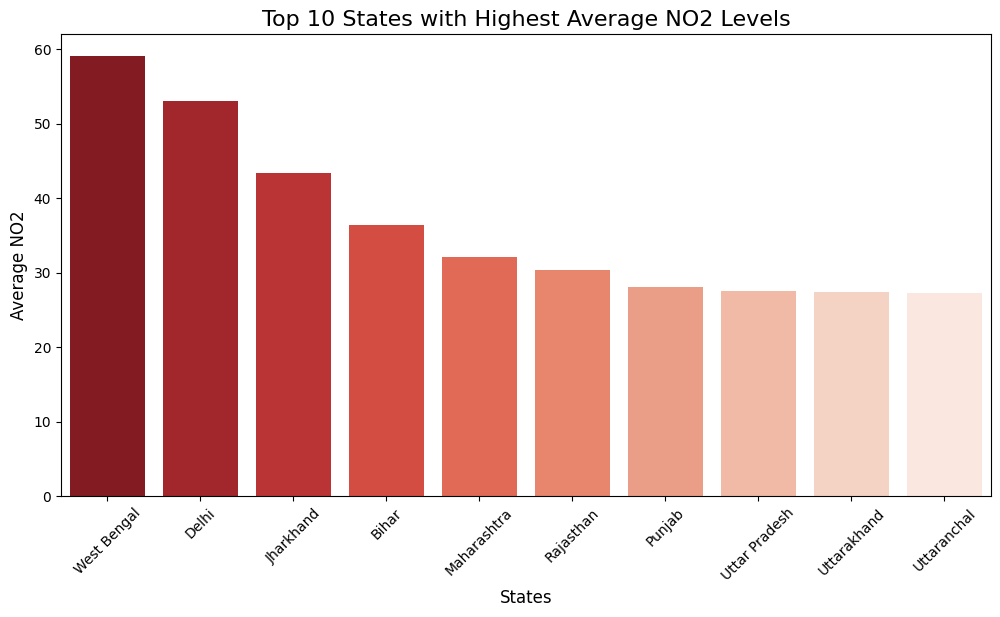

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

state_no2 = df.groupby('state')['no2'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=state_no2.index, y=state_no2.values, palette='Reds_r')
plt.xticks(rotation=45)
plt.title('Top 10 States with Highest Average NO2 Levels', fontsize=16)
plt.xlabel('States', fontsize=12)
plt.ylabel('Average NO2', fontsize=12)
plt.show()

/tmp/ipykernel_1295/3708910839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_no2.index, y=state_no2.values, palette='Reds_r')


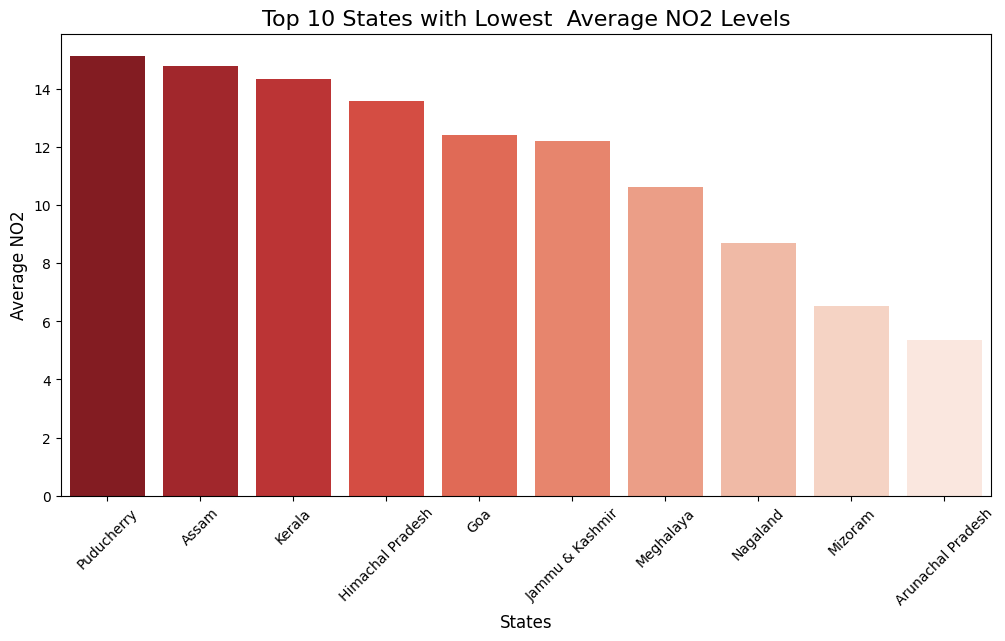

In [ ]:
state_no2 = df.groupby('state')['no2'].mean().sort_values(ascending=False).tail(10)
plt.figure(figsize=(12,6))
sns.barplot(x=state_no2.index, y=state_no2.values, palette='Reds_r')
plt.xticks(rotation=45)
plt.title('Top 10 States with Lowest  Average NO2 Levels', fontsize=16)
plt.xlabel('States', fontsize=12)
plt.ylabel('Average NO2', fontsize=12)
plt.show()

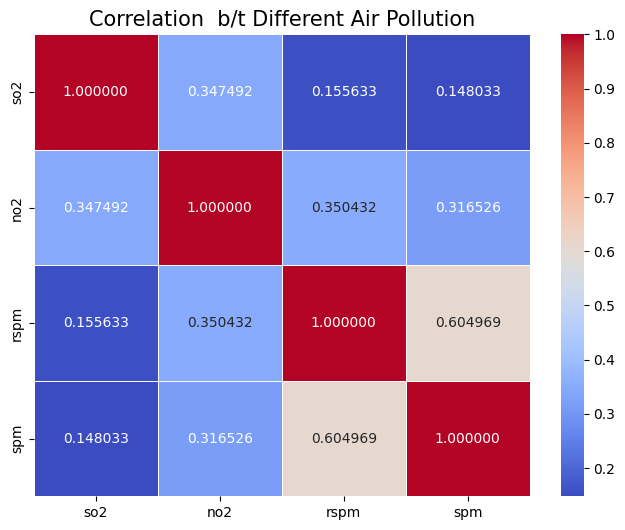

In [ ]:
pollutants_data = df[['so2', 'no2', 'rspm', 'spm']]
plt.figure(figsize=(8,6))
sns.heatmap(pollutants_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt ="2f")
plt.title('Correlation  b/t Different Air Pollution',fontsize=15)
plt.show()

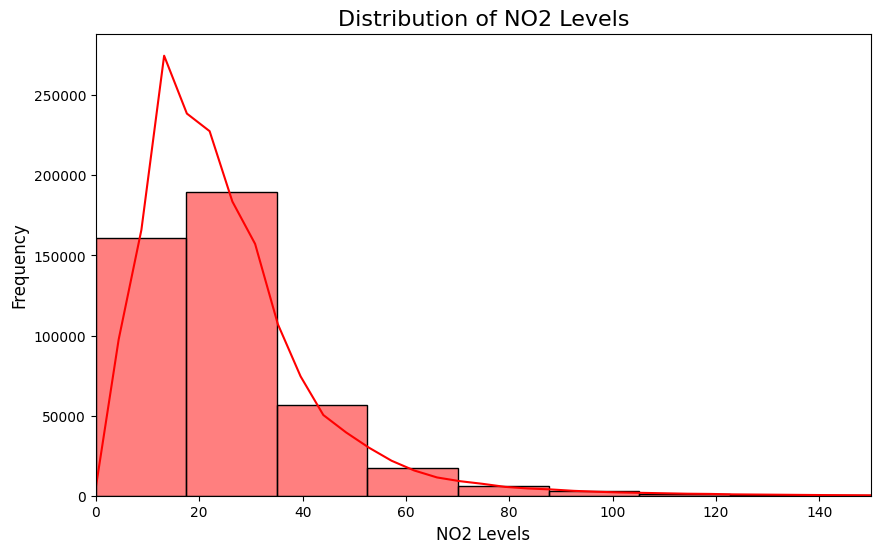

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['no2'], bins=50, kde=True, color='red')
plt.title('Distribution of NO2 Levels', fontsize=16)
plt.xlabel('NO2 Levels', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0,150)
plt.show()

In [ ]:
#df['Air_Quality'] = pd.cut(df['no2'], bins=[0, 50, 100, 150], labels=['Good', 'Moderate', 'Poor'])
df['Air_Quality']  =df['rspm'].apply(lambda x: 1 if x >80 else 0)
print(df['Air_Quality'].value_counts())
x = df[['so2', 'no2', 'spm']]
y = df['Air_Quality']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("\n size of traned data", x_train.shape)
print("\n size of test data", x_test.shape)

Air_Quality
1    250913
0    184822
Name: count, dtype: int64

 size of traned data (348588, 3)

 size of test data (87147, 3)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy* 100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 76.73%

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.71      0.72     36978
           1       0.79      0.81      0.80     50169

    accuracy                           0.77     87147
   macro avg       0.76      0.76      0.76     87147
weighted avg       0.77      0.77      0.77     87147



In [ ]:
import requests

def get_current_weather(api_key, city_name="Lucknow"):
    # WeatherAPI ka sahi endpoint
    base_url = "http://api.weatherapi.com/v1/current.json"

    # API call ke liye parameters
    params = {
        'key': api_key,
        'q': city_name
    }

    # API ko GET request bhejna
    response = requests.get(base_url, params=params)

    # Response check karna (200 matlab successful)
    if response.status_code == 200:
        data = response.json()

        # JSON data se temperature (Celsius) aur mausam ka haal nikalna
        temp = data['current']['temp_c']
        weather_desc = data['current']['condition']['text']

        print(f"{city_name} ka current temperature: {temp}°C")
        print(f"Mausam: {weather_desc}")

        return temp
    else:
        print(f"Error: Data fetch nahi ho paya. Status code: {response.status_code}")
        return None

# Aapki WeatherAPI key jo dashboard par hai
my_api_key = "e951706f3abc4d47bd154507263009"

# Function ko call karna
current_temp = get_current_weather(my_api_key)

Lucknow ka current temperature: 30.5°C
Mausam: Sunny


In [ ]:

city_name = "Lucknow"
current_temp = get_current_weather(my_api_key, city_name)
current_so2 = 15.2
current_no2 = 42.5
current_spm = 110.0

# 3.  (Logistic Regression)
#  2D Array
input_features = [[current_so2, current_no2, current_spm]]
prediction = model.predict(input_features)

# (1 = Bad, 0 = Good)
if prediction[0] == 1:
    aqi_status = "🔴 ख़राब (Poor Air Quality)"
else:
    aqi_status = "🟢 अच्छी (Good Air Quality)"
print("\n" + "="*40)
print(" 🌍 LIVE WEATHER & AIR QUALITY DASHBOARD 🌍")
print("="*40)
print(f"📍 लोकेशन (Location) : {city_name}")
print(f"🌡️: {current_temp}°C")
print("-" * 40)
print(f"🧪 SO2 only           : {current_so2}")
print(f"🧪 NO2 only          : {current_no2}")
print(f"🧪 SPM 0nly          : {current_spm}")
print("-" * 40)
print(f"⚠️ machine learning report : quality of air {aqi_status} है।")
print("="*40)

Lucknow ka current temperature: 30.5°C
Mausam: Sunny

 🌍 LIVE WEATHER & AIR QUALITY DASHBOARD 🌍
📍 लोकेशन (Location) : Lucknow
🌡️: 30.5°C
----------------------------------------
🧪 SO2 only           : 15.2
🧪 NO2 only          : 42.5
🧪 SPM 0nly          : 110.0
----------------------------------------
⚠️ machine learning report : quality of air 🟢 अच्छी (Good Air Quality) है।


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
joblib.dump(model, 'air_quality_model.pkl')
print("Model Saved!")
!pip install streamlit -q
!npm install localtunnel -q

Model Saved!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 53.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
%%writefile app.py
import streamlit as st
import requests
import joblib
import numpy as np

# मॉडल लोड करना
model = joblib.load('air_quality_model.pkl')
api_key = "e951706f3abc4d47bd154507263009"

def get_current_weather(city_name):
    base_url = "http://api.weatherapi.com/v1/current.json"
    params = {'key': api_key, 'q': city_name}
    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
        return data['current']['temp_c'], data['current']['condition']['text']
    return None, None

# (UI)
st.set_page_config(page_title="Air Quality Dashboard", page_icon="🌍")
st.title("🌍 Live Weather & Air Quality Dashboard")

#
st.sidebar.header("📍 Your Location")
city = st.sidebar.text_input("enter the city name ", "Lucknow")

if city:
    temp, weather = get_current_weather(city)
    if temp is not None:
        st.sidebar.success(f": {temp}°C")
        st.sidebar.info(f"🌤️ : {weather}")
    else:
        st.sidebar.error("if city is not found or api problem")

#
st.markdown("### 🧪 (Pollution Levels) ")
col1, col2, col3 = st.columns(3)
with col1:
    so2 = st.number_input("SO2 only ", min_value=0.0, value=15.2)
with col2:
    no2 = st.number_input("NO2 only", min_value=0.0, value=42.5)
with col3:
    spm = st.number_input("SPM only", min_value=0.0, value=110.0)

if st.button("🚀 Check Air Quality"):
    features = np.array([[so2, no2, spm]])
    prediction = model.predict(features)

    st.markdown("---")
    st.markdown("### 🤖 machine learning report:")
    if prediction[0] == 1:
        st.error("🔴 ** (Poor Air Quality)** - stay Safe !")
    else:
        st.success("🟢 ** (Good Air Quality)** - Enjoy the weather!")

Overwriting app.py


In [ ]:
#ngrok config add-authtoken $YOUR_AUTHTOKEN
# 1. pyngrok library install karein
!pip install pyngrok -q

# 2. Purane processes (localtunnel aur purana streamlit) ko band karein
import os
os.system("pkill -f localtunnel")
os.system("pkill -f streamlit")

# 3. Streamlit app ko background mein run karein
os.system("streamlit run app.py &>/dev/null&")

# 4. ngrok setup karein aur link generate karein
from pyngrok import ngrok

# Niche quotes ke andar apna copy kiya hua ngrok authtoken paste karein
NGROK_AUTH_TOKEN = "3K2NMfkHuGu393C0GnAnG1tA2JN_57JFZgtYVAeHavgrZfEG9"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Purane ngrok connections clear karein
ngrok.kill()

# Port 8501 (Streamlit ka default port) ke liye tunnel start karein
public_url = ngrok.connect(8501).public_url
print(f"’’ Aapki Live Website ka naya link: {public_url}")

’’ Aapki Live Website ka naya link: https://sporty-vantage-cheddar.ngrok-free.dev
